# imports and data loading

In [1]:
from model_pipelines.xgb_classifier import *
from model_pipelines.check_calibration import *
from model_pipelines.auxilliary_functions import *
from eda.scoring_function import score_model_optimal_k
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

In [20]:
# do not change project up to project root
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])
#======== run variables ======================================
EXP_NAME = "ks" # set run name
EXP_DIR = project_root / "experiment_results" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
#filenames to save output
FILE_SUBSETS_RESULTS_DF= EXP_DIR / "all_subsets_results_before_tuning.csv"
FILE_ALL_SUBSETS_DICT= EXP_DIR / "all_subsets_dict.json"
FILE_BEST_AFTER_TUNING = EXP_DIR / "top10_subsets_hyperparam_tuning_dict.json"
FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_mulitrun_check_dict.json"
FILE_CV_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_cv_dict.json"
PLOT_DIR = EXP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
# Check of directories
print(f" Root: {project_root}")
print(EXP_DIR)

 Root: C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\ks


In [3]:
#load data (full training data)
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")

In [4]:
# load a dict of all columns selected (another dict may need to be passed)
selected_cols_dict=joblib.load("C:\\Users\\andrz\\Downloads\\selected_features_dictionary.joblib")


In [21]:
#extract the right subset of columns (3 options - for all features, for model features, for statistical features, select one and comment out the others)
selected_second_level_subset=selected_cols_dict['KS'] #for one statistical method, just change the key if needed
selected_second_level_subset=selected_second_level_subset[:10] #get only 10 best features (speeds up computation massivly)
# selected_second_level_subset=unpack_whole_feature_dict(selected_cols_dict,extract='common') # for features found by all methods, if all features found by different methods, use extract='all_found'
# selected_second_level_subset=unpack_model_feature_dict(selected_cols_dict,'rf',extract='common') # for selecting the features found by all xgb (or possibly rf - change second argument) models, extract works as in the previous example

In [22]:
x_t,x_tst,y_t,y_tst=train_test_split(x.loc[:,selected_second_level_subset],y,test_size=0.2,random_state=7)

# check all combinations of the selected features for one configuration of xgb model

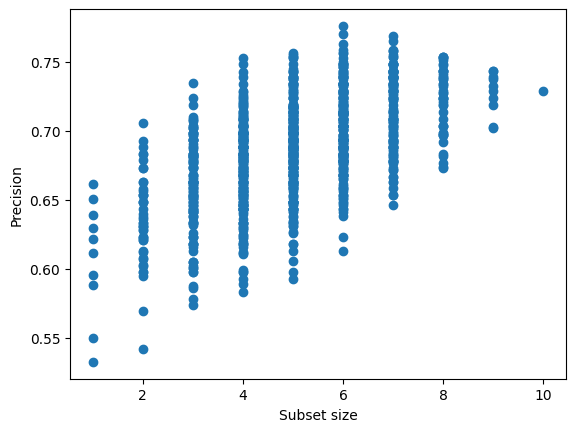

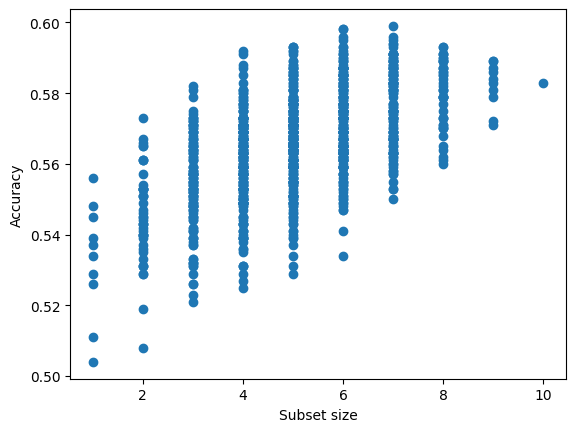

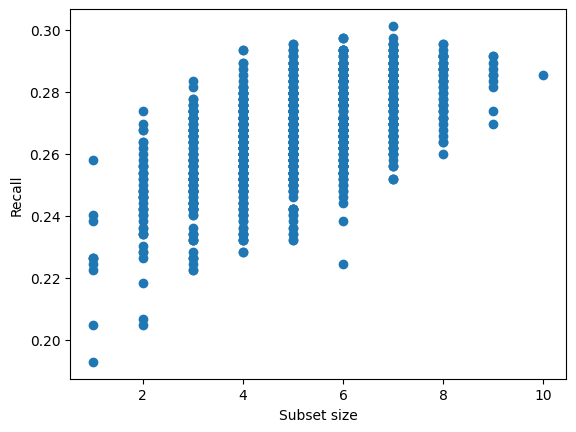

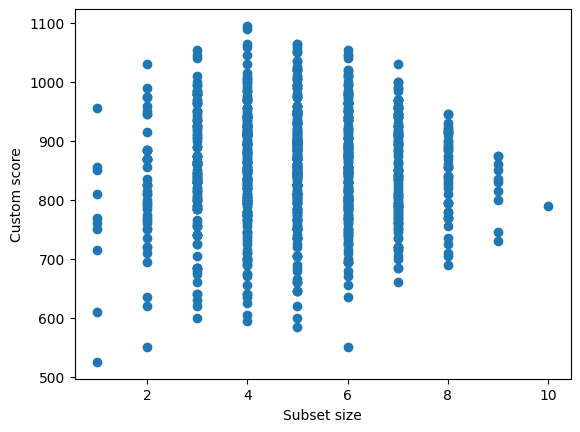

In [23]:
best_model,best_ft,df,all_subsets=train_model_all_combinations(x_t,y_t,x_tst,y_tst,max_subset=selected_second_level_subset,return_metrics=True)

In [17]:
# #reload if needed:
# df=pd.read_csv(FILE_SUBSETS_RESULTS_DF,index_col='Subset index')
# with open(FILE_ALL_SUBSETS_DICT, 'r') as file:
#     all_subsets = json.load(file)
# all_subsets = {int(k): v for k, v in all_subsets.items()}

In [24]:
df=df.sort_values(by="Precision", ascending=False)
df_top10_prec=df.head(10)

print(df_top10_prec)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
334                 1045.0   0.776042     0.598  0.293307
214                 1055.0   0.770408     0.598  0.297244
874                 1030.0   0.768844     0.599  0.301181
970                 1000.0   0.765306     0.596  0.295276
342                 1045.0   0.762626     0.596  0.297244
746                 1000.0   0.758794     0.595  0.297244
365                 1040.0   0.758794     0.595  0.297244
350                  990.0   0.757576     0.594  0.295276
470                  990.0   0.757576     0.594  0.295276
458                 1020.0   0.756345     0.593  0.293307


In [25]:
df=df.sort_values(by="Custom Score", ascending=False)
df_top10_score=df.head(10)

print(df_top10_score)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
337                 1095.0   0.752525     0.592  0.293307
209                 1090.0   0.748744     0.591  0.293307
465                 1065.0   0.753769     0.593  0.295276
325                 1065.0   0.742424     0.588  0.289370
597                 1065.0   0.753769     0.593  0.295276
82                  1060.0   0.738693     0.587  0.289370
338                 1060.0   0.756345     0.593  0.293307
210                 1055.0   0.752525     0.592  0.293307
13                  1055.0   0.723618     0.581  0.283465
214                 1055.0   0.770408     0.598  0.297244


In [26]:
df.to_csv(FILE_SUBSETS_RESULTS_DF, index=True)
save_dict_to_json(all_subsets,FILE_ALL_SUBSETS_DICT)


Successfully saved data to C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\ks\all_subsets_dict.json


# for top 10 feature subsets conduct hyperparameter tuning, at one split.

In [31]:
#initialize a dict for the results of hyperparameter tuning for top 10 subsets
top10_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in df_top10_prec.index
}

In [32]:
for ind in df_top10_prec.index:
    print("=========================================")
    print(f"subset {ind}: {all_subsets[ind]}")
    print("=========================================")
    best_c_hyperparams,best_p_hyperparams=final_xgb_hyperparameter_grid_optimizer(x_t.loc[:,all_subsets[ind]],y_t,x_tst.loc[:,all_subsets[ind]],y_tst)
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    xgb.fit(x_t.loc[:,all_subsets[ind]],y_t)
    y_pred_proba=xgb.predict_proba(x_tst.loc[:,all_subsets[ind]])[:,1]
    best_score,best_threshold, best_k, best_fp, best_tp=score_model_optimal_k(y_tst,y_pred_proba,len(all_subsets[ind]),keep_fp_tp=True,max_k=200,feature_penalty=40)
    top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']=best_c_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_p_hyperparams']=best_p_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_threshold']=best_threshold
    top10_hyperparameter_tuning_result_dict[ind]['best_score']=best_score
    top10_hyperparameter_tuning_result_dict[ind]['best_fp']=best_fp
    top10_hyperparameter_tuning_result_dict[ind]['best_tp']=best_tp
    top10_hyperparameter_tuning_result_dict[ind]['subset_list']=all_subsets[ind] # added for easier reloading
    print("=======================================")
    print(f"Score for subset {all_subsets[ind]}")
    print(f"best score: {best_score}, best threshold: {best_threshold}, fp:{best_fp}, tp:{best_tp}")
    print(f"best custom hyperparameters: {best_c_hyperparams}")
    print(f"best precision hyperparameters: {best_p_hyperparams}")
    print("=======================================")
save_dict_to_json(top10_hyperparameter_tuning_result_dict,FILE_BEST_AFTER_TUNING)

subset 334: ['V224', 'V255', 'V11', 'V265', 'V191', 'V309']
Score for subset ['V224', 'V255', 'V11', 'V265', 'V191', 'V309']
best score: 1070, best threshold: 0.5636477470397949, fp:46, tp:154
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 500, 'lr': 0.01}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 500, 'lr': 0.01}
subset 214: ['V224', 'V255', 'V11', 'V176', 'V191', 'V329']
Score for subset ['V224', 'V255', 'V11', 'V176', 'V191', 'V329']
best score: 1060, best threshold: 0.5756837725639343, fp:46, tp:153
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 2000, 'lr': 0.005}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 1000, 'lr': 0.01}
subset 874: ['V224', 'V255', 'V265', 'V161', 'V191', 'V309', 'V175']
Score for subset ['V224', 'V255', 'V265', 'V161', 'V191', 'V309', 'V175']
best score: 1000, best threshold: 0.6332411766052246, fp:48, tp:152
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}

In [33]:
#create a df with the scores of the top10 subsets for easier further selection and get 4 top subset indices
auxliary_data = [
    {'ind': key, 'score': value['best_score']}
    for key, value in top10_hyperparameter_tuning_result_dict.items()
]
auxiliary_df = pd.DataFrame(auxliary_data)
auxiliary_df=auxiliary_df.sort_values(by="score", ascending=False)
top10_subset_indices=auxiliary_df.head(10).loc[:,"ind"].tolist()
# a dictionary for results of multi-split check
top10_multisplit_result_dict = {
    idx: {}
    for idx in top10_subset_indices
}

In [34]:
print(auxiliary_df)

   ind  score
9  458   1110
0  334   1070
1  214   1060
6  365   1055
4  342   1045
8  470   1015
3  970   1005
7  350   1005
5  746   1000
2  874   1000


In [35]:
for ind in top10_subset_indices:
    scores,precs=check_xgb_model_with_multi_split(x.loc[:, top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y,max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'], n_estimators=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['n_estimators'], learning_rate=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['lr'],n_checks=50,threshold=top10_hyperparameter_tuning_result_dict[ind]['best_threshold'])
    top10_multisplit_result_dict[ind]['scores']=scores
    top10_multisplit_result_dict[ind]['precs']=precs
    print(f"check done for index: {ind}")
save_dict_to_json(top10_multisplit_result_dict,FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS)

no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives

C:\Users\andrz\AppData\Local\Temp\ipykernel_13980\2730525874.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


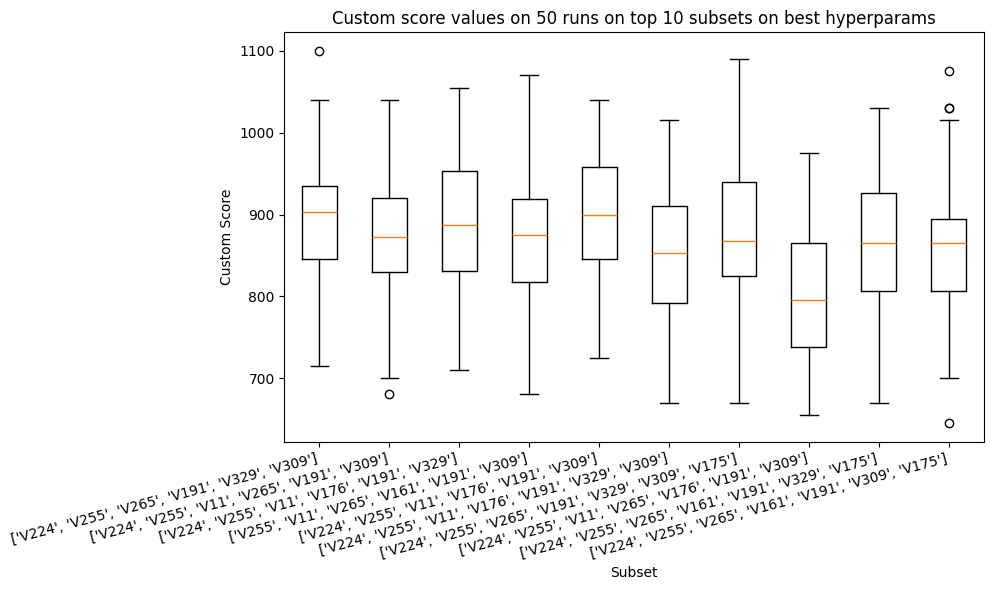

In [36]:
#plotting - custom scores (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['scores'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Custom Score")
plt.title("Custom score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "custom_score_50runs_boxplot.png"))
plt.show()

C:\Users\andrz\AppData\Local\Temp\ipykernel_13980\3926348023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


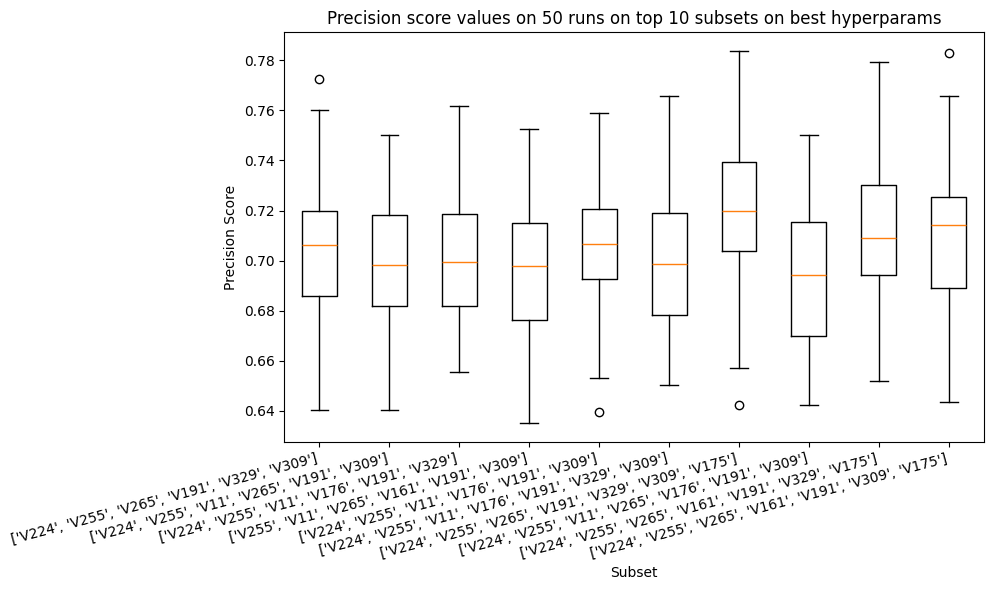

In [37]:
#plotting - precisions (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['precs'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Precision Score")
plt.title("Precision score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "precision_50runs_boxplot.png"))
plt.show()

In [38]:
top10_cv_result_dict={
    ind:{}
    for ind in top10_subset_indices
}
for ind in top10_subset_indices:
    print(f"checking cv score for subset: {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    all_y_pred=(all_y_prob>score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))[1]).astype(int)
    print(precision_score(all_y_test,all_y_pred))
    top10_cv_result_dict[ind]["precision"]=precision_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["accuracy"]=accuracy_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["recall"]=recall_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["cv_custom_score"],top10_cv_result_dict[ind]["cv_best_threshold"]=score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True)[:2]
    print(score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True))
    print("===============================================")
save_dict_to_json(top10_cv_result_dict,FILE_CV_TOP10_SUBSETS_RESULTS)

checking cv score for subset: ['V224', 'V255', 'V265', 'V191', 'V329', 'V309']
0.7187187187187187
(4585, np.float32(0.6143685), 1000, 281, 719)
checking cv score for subset: ['V224', 'V255', 'V11', 'V265', 'V191', 'V309']
0.7207661290322581
(4575, np.float32(0.61468947), 993, 277, 716)
checking cv score for subset: ['V224', 'V255', 'V11', 'V176', 'V191', 'V329']
0.7177177177177178
(4570, np.float32(0.6192116), 1000, 282, 718)
checking cv score for subset: ['V255', 'V11', 'V265', 'V161', 'V191', 'V309']
0.7177177177177178
(4570, np.float32(0.6148883), 1000, 282, 718)
checking cv score for subset: ['V224', 'V255', 'V11', 'V176', 'V191', 'V309']
0.7207207207207207
(4615, np.float32(0.6196516), 1000, 279, 721)
checking cv score for subset: ['V224', 'V255', 'V11', 'V176', 'V191', 'V329', 'V309']
0.7167167167167167
(4355, np.float32(0.61743593), 1000, 283, 717)
checking cv score for subset: ['V224', 'V255', 'V265', 'V191', 'V329', 'V309', 'V175']
0.7167167167167167
(4355, np.float32(0.646154

# before decision run calibration check

checking calibration for subset ['V224', 'V255', 'V265', 'V191', 'V329', 'V309']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.332
Bin  2 | n= 500 | mean_pred=0.363 | frac_pos=0.354
Bin  3 | n= 500 | mean_pred=0.393 | frac_pos=0.372
Bin  4 | n= 500 | mean_pred=0.422 | frac_pos=0.406
Bin  5 | n= 499 | mean_pred=0.451 | frac_pos=0.445
Bin  6 | n= 501 | mean_pred=0.486 | frac_pos=0.507
Bin  7 | n= 500 | mean_pred=0.530 | frac_pos=0.536
Bin  8 | n= 500 | mean_pred=0.582 | frac_pos=0.586
Bin  9 | n= 500 | mean_pred=0.655 | frac_pos=0.678
Bin 10 | n= 500 | mean_pred=0.781 | frac_pos=0.760


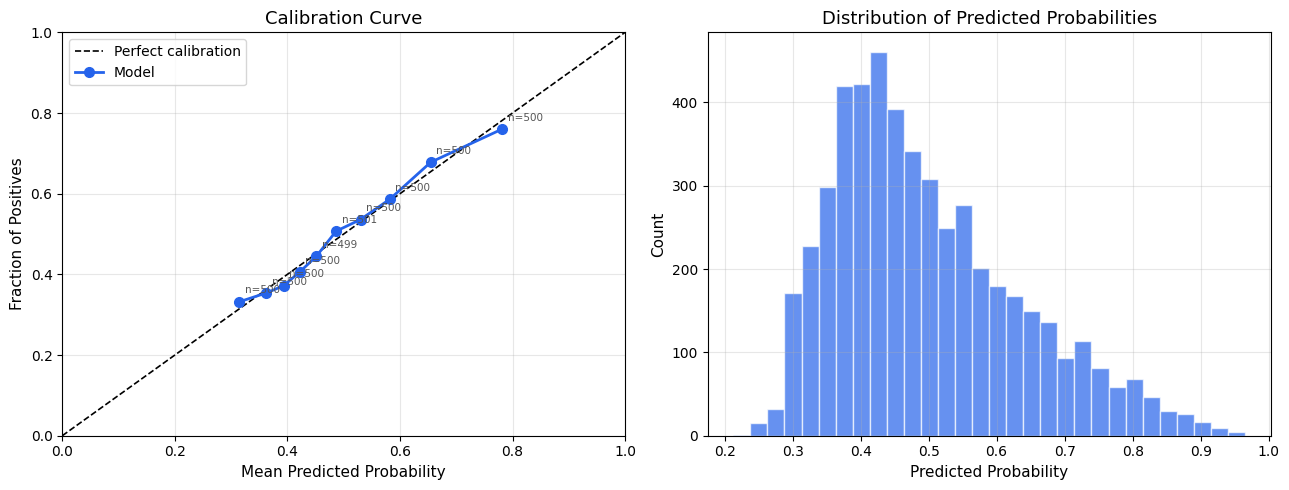

checking calibration for subset ['V224', 'V255', 'V11', 'V265', 'V191', 'V309']
Bin  1 | n= 500 | mean_pred=0.321 | frac_pos=0.322
Bin  2 | n= 499 | mean_pred=0.364 | frac_pos=0.389
Bin  3 | n= 501 | mean_pred=0.394 | frac_pos=0.365
Bin  4 | n= 500 | mean_pred=0.421 | frac_pos=0.392
Bin  5 | n= 500 | mean_pred=0.451 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.524
Bin  7 | n= 500 | mean_pred=0.529 | frac_pos=0.512
Bin  8 | n= 500 | mean_pred=0.581 | frac_pos=0.592
Bin  9 | n= 500 | mean_pred=0.654 | frac_pos=0.684
Bin 10 | n= 500 | mean_pred=0.781 | frac_pos=0.752


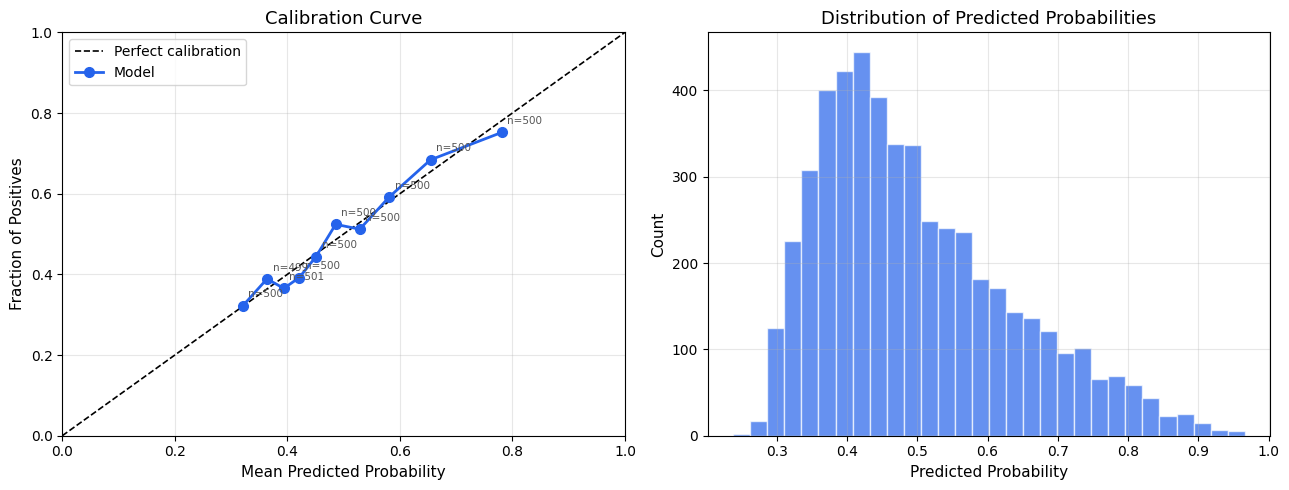

checking calibration for subset ['V224', 'V255', 'V11', 'V176', 'V191', 'V329']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.320
Bin  2 | n= 499 | mean_pred=0.360 | frac_pos=0.347
Bin  3 | n= 500 | mean_pred=0.390 | frac_pos=0.368
Bin  4 | n= 501 | mean_pred=0.418 | frac_pos=0.399
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.462
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.492
Bin  7 | n= 500 | mean_pred=0.531 | frac_pos=0.528
Bin  8 | n= 500 | mean_pred=0.586 | frac_pos=0.624
Bin  9 | n= 500 | mean_pred=0.661 | frac_pos=0.690
Bin 10 | n= 500 | mean_pred=0.788 | frac_pos=0.746


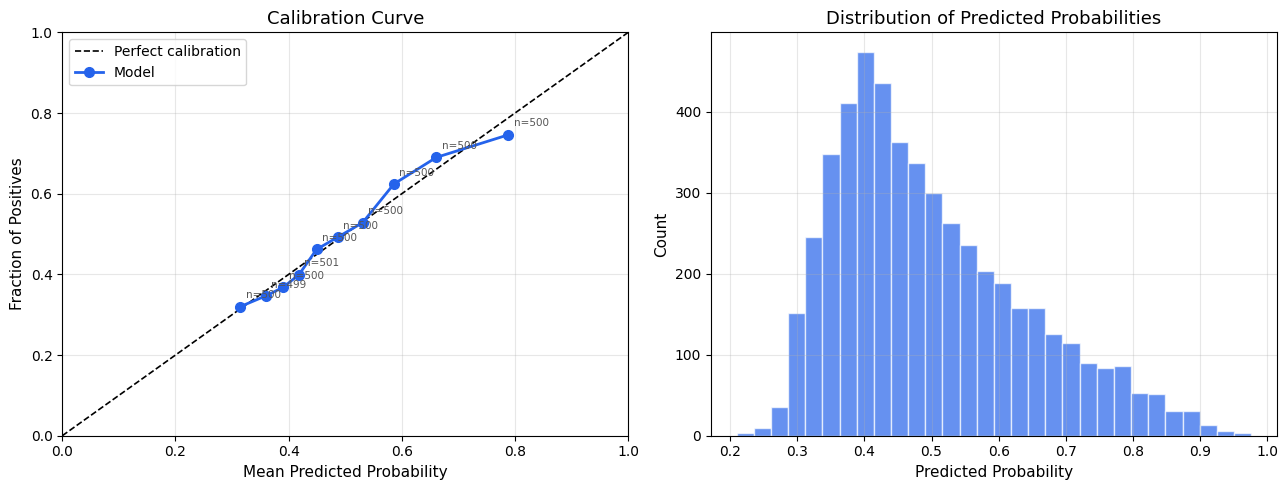

checking calibration for subset ['V255', 'V11', 'V265', 'V161', 'V191', 'V309']
Bin  1 | n= 500 | mean_pred=0.321 | frac_pos=0.332
Bin  2 | n= 500 | mean_pred=0.364 | frac_pos=0.380
Bin  3 | n= 500 | mean_pred=0.393 | frac_pos=0.356
Bin  4 | n= 500 | mean_pred=0.421 | frac_pos=0.402
Bin  5 | n= 500 | mean_pred=0.452 | frac_pos=0.420
Bin  6 | n= 499 | mean_pred=0.487 | frac_pos=0.527
Bin  7 | n= 501 | mean_pred=0.529 | frac_pos=0.545
Bin  8 | n= 500 | mean_pred=0.581 | frac_pos=0.578
Bin  9 | n= 500 | mean_pred=0.654 | frac_pos=0.686
Bin 10 | n= 500 | mean_pred=0.779 | frac_pos=0.750


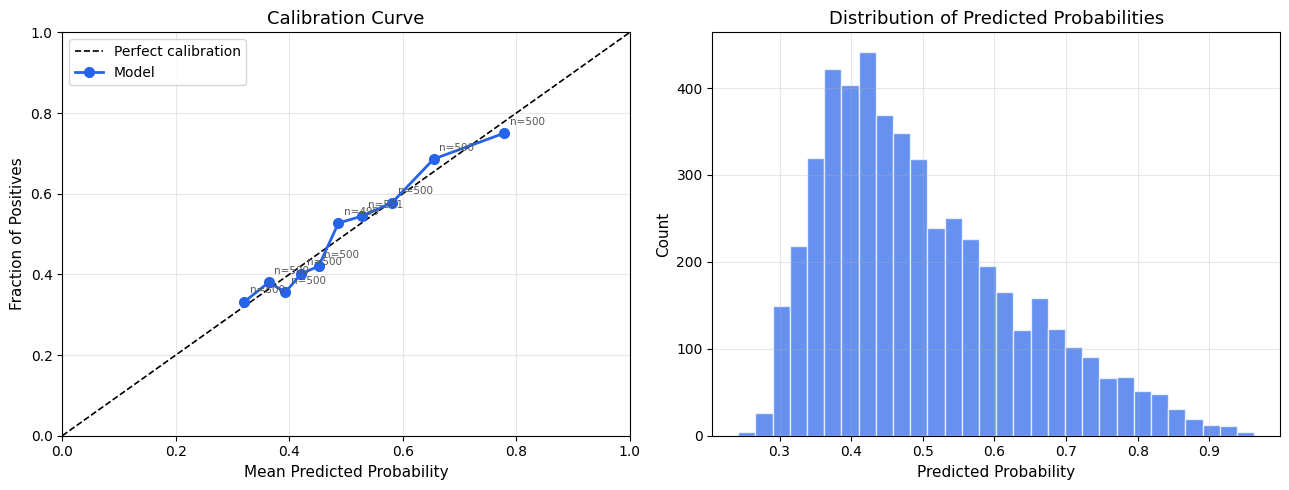

checking calibration for subset ['V224', 'V255', 'V11', 'V176', 'V191', 'V309']
Bin  1 | n= 499 | mean_pred=0.319 | frac_pos=0.311
Bin  2 | n= 501 | mean_pred=0.361 | frac_pos=0.379
Bin  3 | n= 500 | mean_pred=0.390 | frac_pos=0.328
Bin  4 | n= 500 | mean_pred=0.418 | frac_pos=0.436
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.442
Bin  6 | n= 500 | mean_pred=0.485 | frac_pos=0.504
Bin  7 | n= 500 | mean_pred=0.529 | frac_pos=0.532
Bin  8 | n= 500 | mean_pred=0.586 | frac_pos=0.602
Bin  9 | n= 500 | mean_pred=0.661 | frac_pos=0.684
Bin 10 | n= 500 | mean_pred=0.789 | frac_pos=0.758


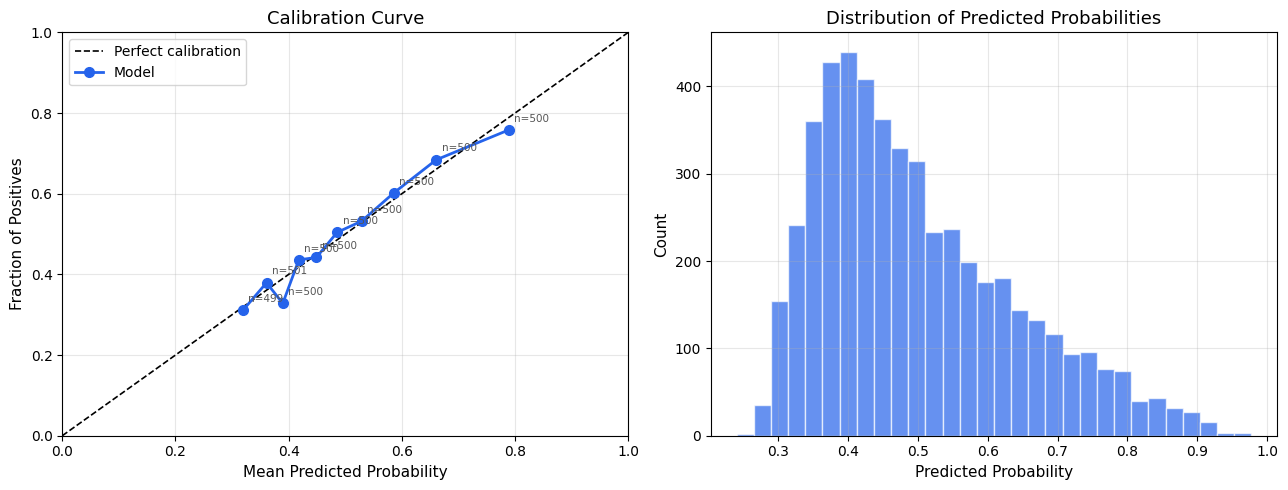

checking calibration for subset ['V224', 'V255', 'V11', 'V176', 'V191', 'V329', 'V309']
Bin  1 | n= 500 | mean_pred=0.314 | frac_pos=0.326
Bin  2 | n= 496 | mean_pred=0.359 | frac_pos=0.353
Bin  3 | n= 504 | mean_pred=0.390 | frac_pos=0.353
Bin  4 | n= 500 | mean_pred=0.419 | frac_pos=0.422
Bin  5 | n= 500 | mean_pred=0.450 | frac_pos=0.458
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.476
Bin  7 | n= 500 | mean_pred=0.530 | frac_pos=0.528
Bin  8 | n= 500 | mean_pred=0.585 | frac_pos=0.626
Bin  9 | n= 500 | mean_pred=0.660 | frac_pos=0.688
Bin 10 | n= 500 | mean_pred=0.787 | frac_pos=0.746


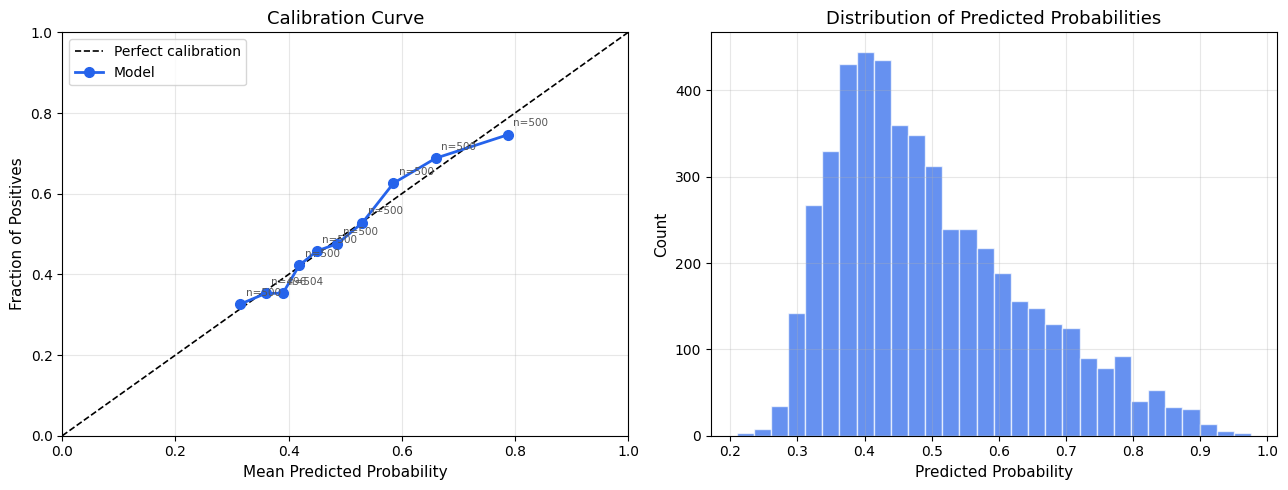

checking calibration for subset ['V224', 'V255', 'V265', 'V191', 'V329', 'V309', 'V175']
Bin  1 | n= 500 | mean_pred=0.265 | frac_pos=0.328
Bin  2 | n= 500 | mean_pred=0.330 | frac_pos=0.336
Bin  3 | n= 500 | mean_pred=0.372 | frac_pos=0.384
Bin  4 | n= 500 | mean_pred=0.410 | frac_pos=0.424
Bin  5 | n= 500 | mean_pred=0.450 | frac_pos=0.430
Bin  6 | n= 500 | mean_pred=0.496 | frac_pos=0.500
Bin  7 | n= 500 | mean_pred=0.548 | frac_pos=0.540
Bin  8 | n= 500 | mean_pred=0.610 | frac_pos=0.600
Bin  9 | n= 500 | mean_pred=0.688 | frac_pos=0.690
Bin 10 | n= 500 | mean_pred=0.818 | frac_pos=0.744


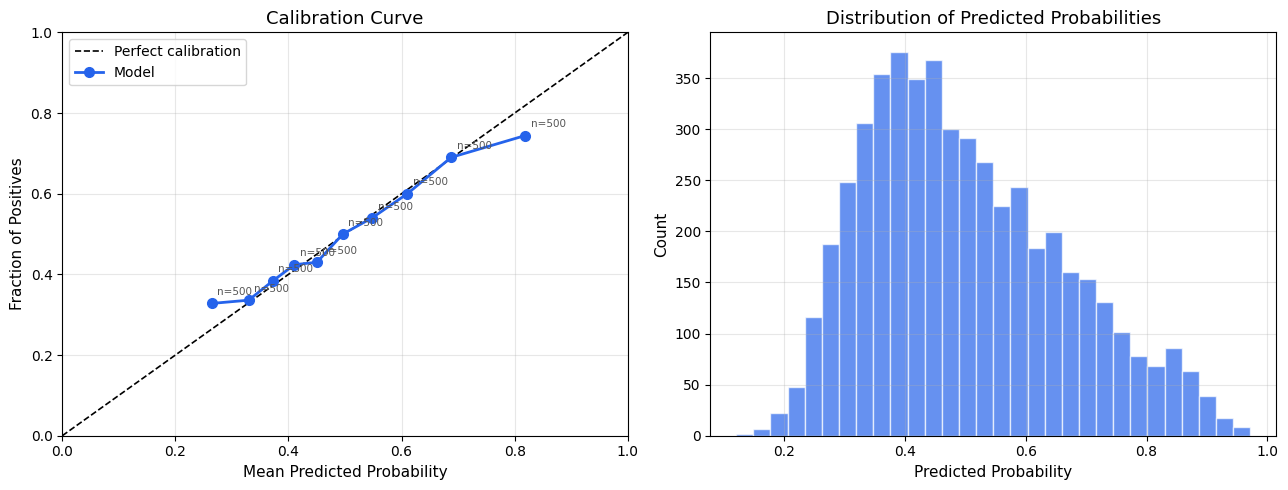

checking calibration for subset ['V224', 'V255', 'V11', 'V265', 'V176', 'V191', 'V309']
Bin  1 | n= 500 | mean_pred=0.147 | frac_pos=0.352
Bin  2 | n= 500 | mean_pred=0.243 | frac_pos=0.384
Bin  3 | n= 500 | mean_pred=0.310 | frac_pos=0.394
Bin  4 | n= 500 | mean_pred=0.376 | frac_pos=0.426
Bin  5 | n= 500 | mean_pred=0.439 | frac_pos=0.468
Bin  6 | n= 500 | mean_pred=0.510 | frac_pos=0.498
Bin  7 | n= 500 | mean_pred=0.588 | frac_pos=0.520
Bin  8 | n= 500 | mean_pred=0.679 | frac_pos=0.586
Bin  9 | n= 500 | mean_pred=0.787 | frac_pos=0.628
Bin 10 | n= 500 | mean_pred=0.911 | frac_pos=0.720


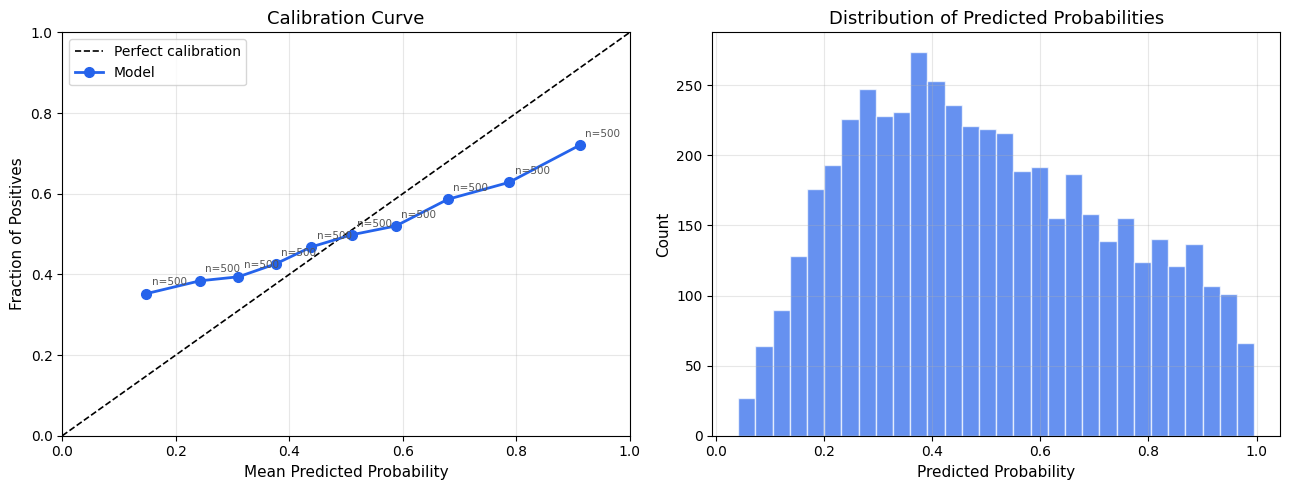

checking calibration for subset ['V224', 'V255', 'V265', 'V161', 'V191', 'V329', 'V175']
Bin  1 | n= 500 | mean_pred=0.220 | frac_pos=0.298
Bin  2 | n= 500 | mean_pred=0.304 | frac_pos=0.376
Bin  3 | n= 500 | mean_pred=0.355 | frac_pos=0.414
Bin  4 | n= 500 | mean_pred=0.399 | frac_pos=0.404
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.474
Bin  6 | n= 500 | mean_pred=0.504 | frac_pos=0.492
Bin  7 | n= 500 | mean_pred=0.563 | frac_pos=0.510
Bin  8 | n= 500 | mean_pred=0.630 | frac_pos=0.576
Bin  9 | n= 500 | mean_pred=0.718 | frac_pos=0.678
Bin 10 | n= 500 | mean_pred=0.856 | frac_pos=0.754


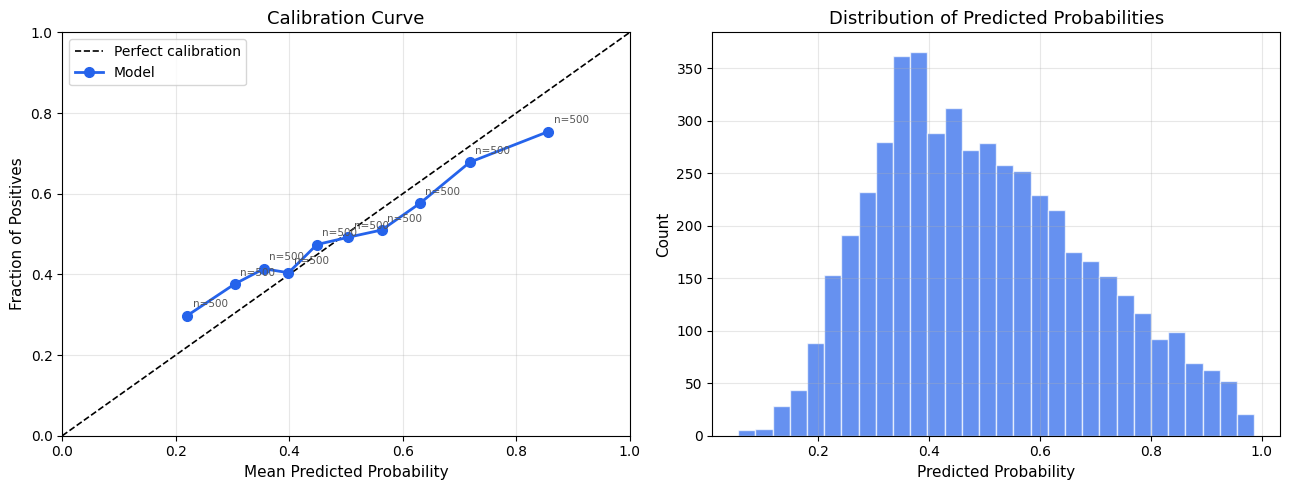

checking calibration for subset ['V224', 'V255', 'V265', 'V161', 'V191', 'V309', 'V175']
Bin  1 | n= 500 | mean_pred=0.320 | frac_pos=0.324
Bin  2 | n= 499 | mean_pred=0.365 | frac_pos=0.375
Bin  3 | n= 501 | mean_pred=0.395 | frac_pos=0.351
Bin  4 | n= 500 | mean_pred=0.423 | frac_pos=0.412
Bin  5 | n= 500 | mean_pred=0.452 | frac_pos=0.448
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.496
Bin  7 | n= 500 | mean_pred=0.528 | frac_pos=0.522
Bin  8 | n= 500 | mean_pred=0.582 | frac_pos=0.610
Bin  9 | n= 500 | mean_pred=0.653 | frac_pos=0.684
Bin 10 | n= 500 | mean_pred=0.780 | frac_pos=0.754


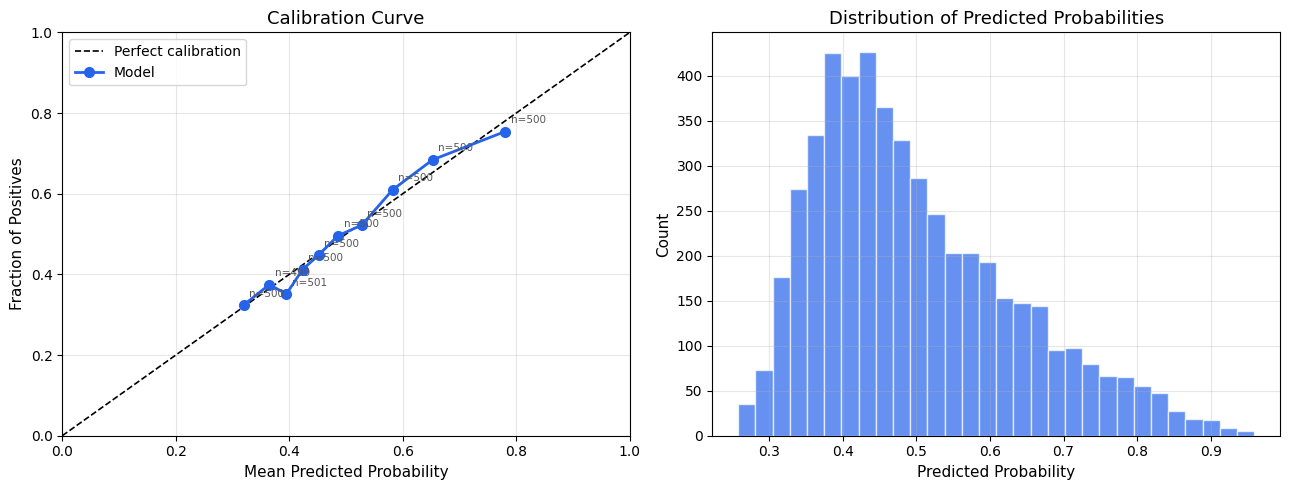

In [39]:
for ind in top10_subset_indices:
    print(f"checking calibration for subset {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    check_calibration(all_y_prob,all_y_test,savename=Path(PLOT_DIR / f"calibration_for_subset_{ind}"))
    print("===============================================")